## Gradient Descent Extensions: Momentum and Adam

In this laboratory session, you will explore two popular extensions of basic Gradient Descent:
1.	Momentum-based Gradient Descent
2.	Adam (Adaptive Moment Estimation)

We will test these methods on three classical benchmark functions in 2D space:
- **Sphere**: a simple, convex, unimodal function that is relatively easy to optimize.
- **Rosenbrock**: features a narrow valley, making convergence more difficult.
- **Rastrigin**: contains many local minima, making it challenging to escape suboptimal points.

By the end of this lab, you should understand how momentum and adaptive step-size techniques help accelerate gradient-based optimization, especially on surfaces with poor curvature or local traps.

### Test Functions
You have been given implementations of the three test functions (Sphere, Rosenbrock, and Rastrigin) along with their gradients, all inheriting from the abstract `Problem` class.


In [2]:
import numpy as np
from abc import ABC, abstractmethod

class Problem(ABC):
    @abstractmethod
    def __call__(self, x: np.ndarray) -> float:
        """Compute the function value at point x."""
        raise NotImplementedError
    
    @abstractmethod
    def grad(self, x: np.ndarray) -> np.ndarray:
        """Compute the gradient at point x."""
        raise NotImplementedError

class Sphere(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(x**2)
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        return 2 * x

class Rosenbrock(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        grad = np.zeros_like(x)
        n = x.size
        grad[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
        for i in range(1, n - 1):
            grad[i] = 200 * (x[i] - x[i-1]**2) - 400 * x[i] * (x[i+1] - x[i]**2) - 2 * (1 - x[i])
        grad[-1] = 200 * (x[-1] - x[-2]**2)
        return grad

class Rastrigin(Problem):
    def __call__(self, x: np.ndarray) -> float:
        A = 10
        n = x.size
        return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        A = 10
        return 2 * x + 2 * np.pi * A * np.sin(2 * np.pi * x)

### Visualization Tools
Here are some already implemented functions that you can use to produce visualizations:

In [3]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def prepare_mesh_grid(
    problem: Problem,
    bounds: tuple[float, float] = (-5.0, 5.0),
    grid_size: int = 50,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x_vals = np.linspace(bounds[0], bounds[1], grid_size)
    y_vals = np.linspace(bounds[0], bounds[1], grid_size)
    X, Y = np.meshgrid(x_vals, y_vals)

    Z = np.zeros_like(X)
    for i in range(grid_size):
        for j in range(grid_size):
            xy = np.array([X[i, j], Y[i, j]])
            Z[i, j] = problem(xy)

    return X, Y, Z, x_vals, y_vals


def plot_3d_surface(
    problem: Problem,
    grid_size: int = 50,
):
    X, Y, Z, _, _ = prepare_mesh_grid(problem=problem, grid_size=grid_size)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

    ax.set_title(problem.__class__.__name__)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y)")

    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.tight_layout()
    plt.show()

def plot_contour_and_paths(
    problem: Problem,
    paths: list[np.ndarray],
    grid_size: int = 200,
    title: str = "",
):
    """
    Create an interactive contour plot of a 2D function and overlay multiple optimization paths.

    Args:
        problem: An instance of a Problem class.
        paths: List of numpy arrays; each array is of shape (epochs, 2) containing an optimization trajectory.
        title: Title for the plot.
    """
    _, _, Z, x_vals, y_vals = prepare_mesh_grid(problem, grid_size=grid_size)

    fig = go.Figure(
        data=go.Contour(
            x=x_vals,
            y=y_vals,
            z=Z,
            colorscale="Viridis",
            contours=dict(showlines=False),
            colorbar=dict(title="Function Value"),
        )
    )

    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'pink', 'brown']
    
    for idx, path in enumerate(paths):
        color_idx = idx % len(colors)
        fig.add_trace(
            go.Scatter(
                x=path[:, 0],
                y=path[:, 1],
                mode="lines+markers",
                marker=dict(size=4),
                line=dict(width=2, color=colors[color_idx]),
                name=f"Run {idx+1}",
                showlegend=True,
            )
        )

    fig.update_layout(
        title=title, xaxis_title="x", yaxis_title="y", width=800, height=700,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig.show()

### 1. Getting familiar with optimization test problems
Understand the landscapes of the test functions to predict optimization challenges.
Visualize each function. Use `plot_3d_surface` to generate a 3D surface plot for each function (Sphere, Rosenbrock, Rastrigin). Use `plot_contour_and_paths` with an empty paths list to generate a 2D contour plot for each function.

Which function appears easiest to optimize? Hardest? Why?


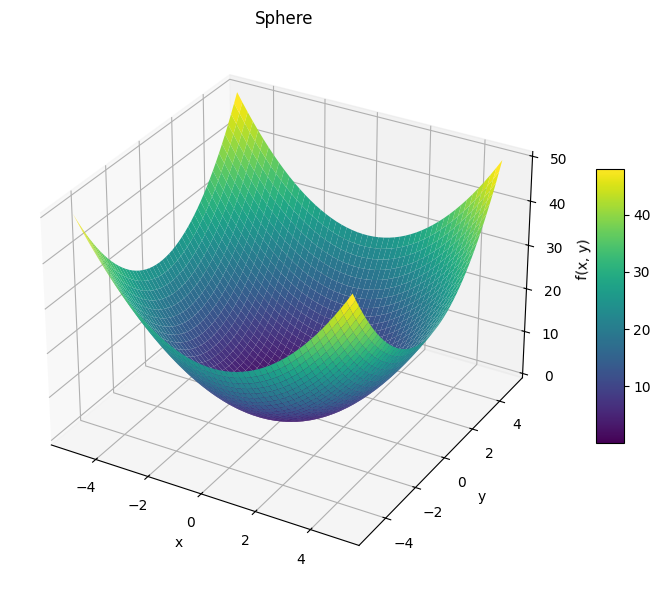

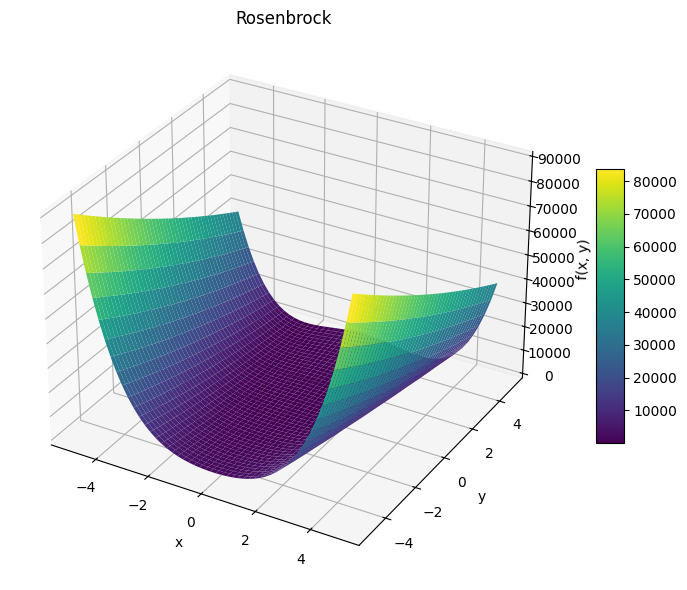

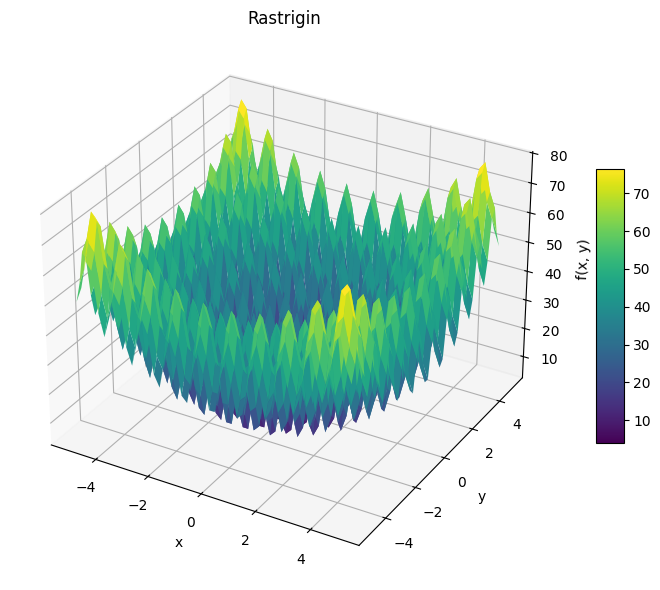

In [4]:
plot_3d_surface(Sphere())
plot_3d_surface(Rosenbrock())
plot_3d_surface(Rastrigin())

plot_contour_and_paths(
    problem=Sphere(),
    paths=[]
)

plot_contour_and_paths(
    problem=Rosenbrock(),
    paths=[]
)

plot_contour_and_paths(
    problem=Rastrigin(),
    paths=[]
)



### 2. Momentum method

Your task is to implement the Momentum optimizer with the interface:
```python
def momentum(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta: float,
    number_of_epochs: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    ...
```
Where:
- initial_solution is your starting point.
- alpha is the learning rate.
- beta is the momentum parameter (commonly 0.9).

Returns a tuple of:
- positions: np.ndarray of shape (number_of_epochs, dim) — the optimization path.
- function_values: np.ndarray of shape (number_of_epochs,) — function value at each epoch.
- velocity_norms: np.ndarray of shape (number_of_epochs,) — velocity norm at each epoch.


In [17]:
def momentum(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta: float,
    number_of_epochs: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    
    solution = initial_solution.copy()
    velocity = np.zeros_like(solution)
    dim = solution.shape[0]

    positions = np.zeros((number_of_epochs, dim))
    function_values = np.zeros(number_of_epochs)
    velocity_norms = np.zeros(number_of_epochs)

    for epoch in range(number_of_epochs):
        grad = problem.grad(solution)

        positions[epoch] = solution.copy()
        function_values[epoch] = problem(solution)
        velocity_norms[epoch] = np.linalg.norm(velocity)

        if epoch < number_of_epochs - 1:
            velocity = beta * velocity + grad
            solution = solution - alpha * velocity

        

    return positions, function_values, velocity_norms



### 3. Experiments with Momentum

Observe how Momentum performs on different functions. Use following parameters:
- `initial_solution = np.array([2.0, 2.0])`, 
- `alpha = 0.01`, 
- `beta = 0.9`, 
- `number_of_epochs = 100`. 

For each function, plot:
- Function value vs. epoch.
- For Rosenbrock and Rastrigin functions, experiment with decreasing the learning rate `alpha` (try values like 0.001 and 0.0001) to observe how it affects convergence.
- Velocity norm (e.g `np.linalg.norm`) vs. epoch. Note: velocity is a **vector** (one component per dimension), so we cannot plot it directly as a single value. Instead, we take its norm — a scalar that measures the overall magnitude of the velocity vector.

How does the velocity norm evolve? Does it correlate with convergence speed?


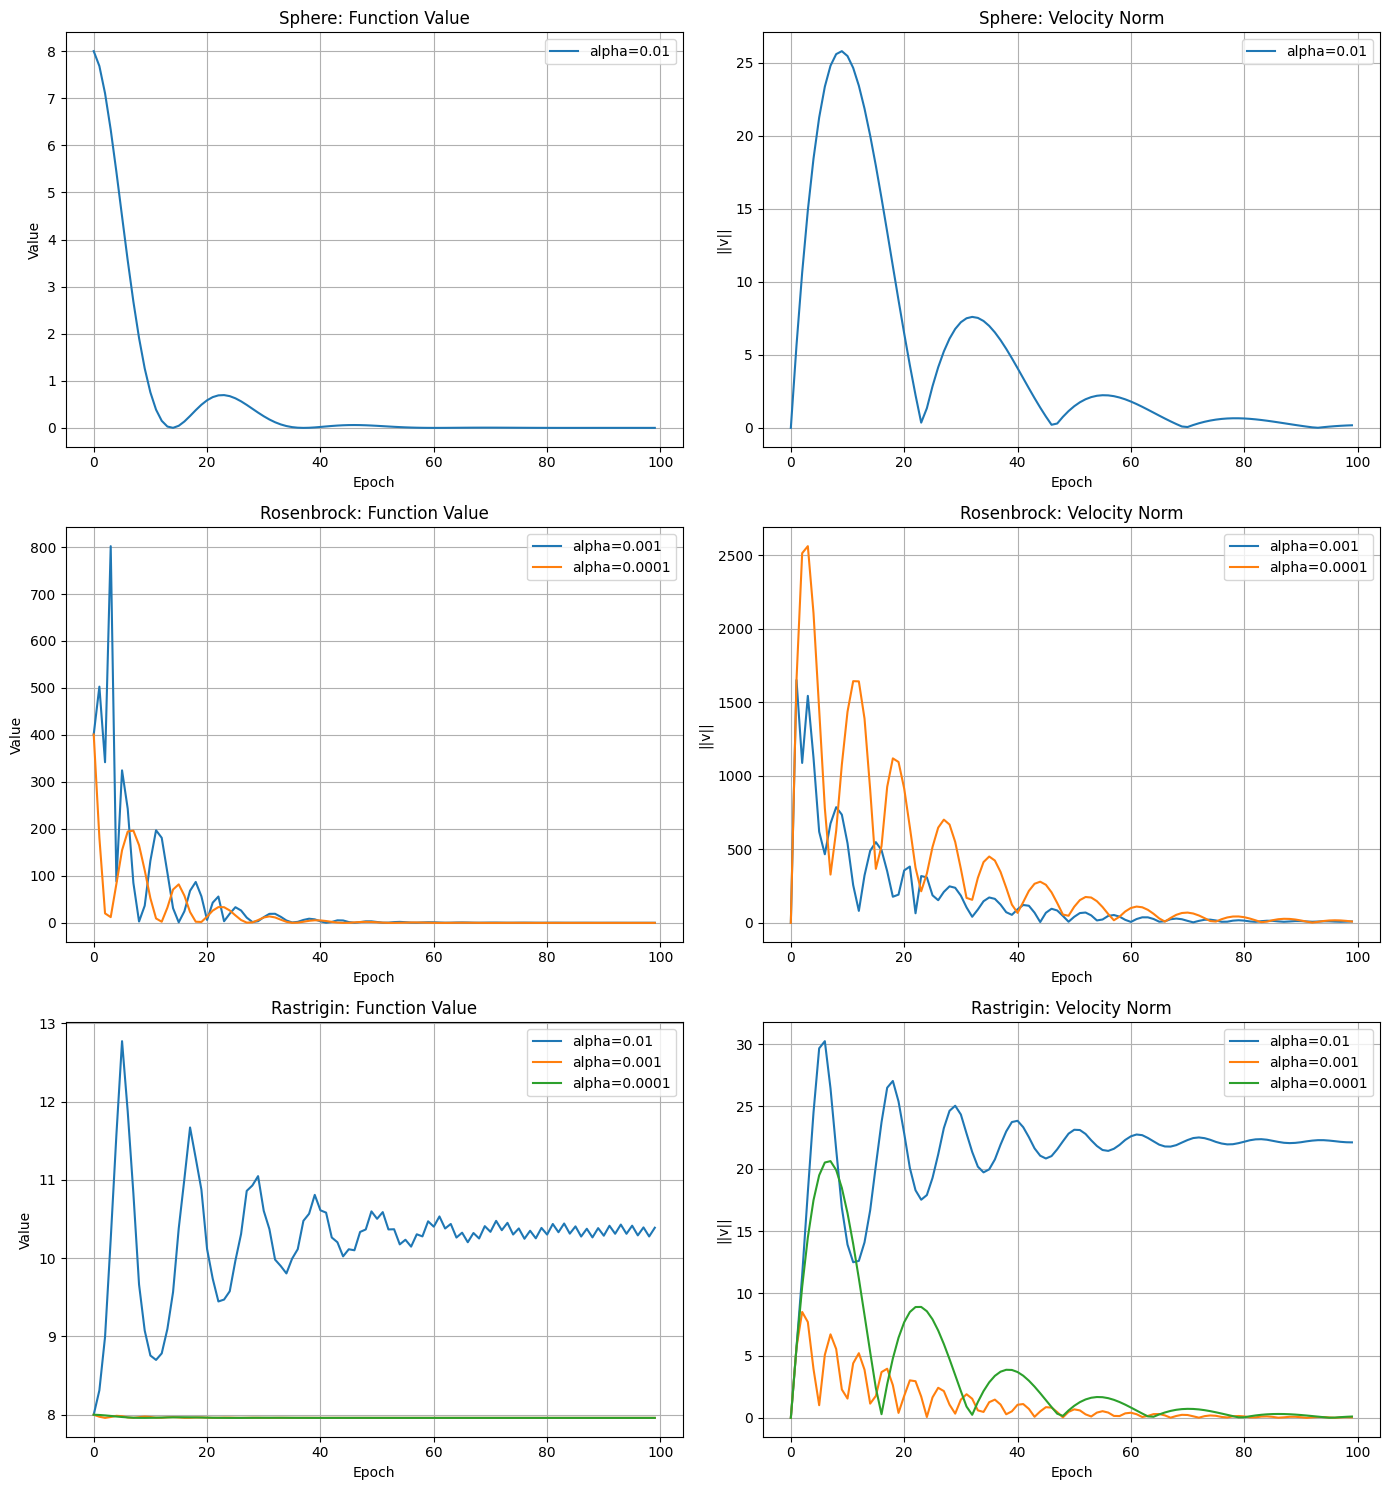

In [30]:
import numpy as np
import matplotlib.pyplot as plt

initial_solution = np.array([2.0, 2.0])
beta = 0.9
number_of_epochs = 100
problems = [("Sphere", Sphere(), [0.01]), 
            ("Rosenbrock", Rosenbrock(), [0.001, 0.0001]), 
            ("Rastrigin", Rastrigin(), [0.01, 0.001, 0.0001])]

fig, axes = plt.subplots(len(problems), 2, figsize=(14, 15))

for i, (name, prob, alphas) in enumerate(problems):
    for a in alphas:
        pos, vals, v_norms = momentum(prob, initial_solution, a, beta, number_of_epochs)
        
        axes[i, 0].plot(vals, label=f"alpha={a}")
        axes[i, 0].set_title(f"{name}: Function Value")
        axes[i, 0].set_xlabel("Epoch")
        axes[i, 0].set_ylabel("Value")
        axes[i, 0].legend()
        axes[i, 0].grid(True)

        axes[i, 1].plot(v_norms, label=f"alpha={a}")
        axes[i, 1].set_title(f"{name}: Velocity Norm")
        axes[i, 1].set_xlabel("Epoch")
        axes[i, 1].set_ylabel("||v||")
        axes[i, 1].legend()
        axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

**How does the velocity norm evolve? Does it correlate with convergence speed?**

The velocity norm (||v||) acts like the speed of the optimizer.
Initially, it spikes or stays high as the optimizer gains momentum and rolls down the steepest part of the slope.

During Optimization it goes up and down. This happens because the momentum carries the optimizer past the minimum, causing it to "overshoot" and then swing back.

As the optimizer settles near the minimum, the velocity norm gradually decays toward zero.

**Does it correlate with convergence speed?**
Yes, positively.

High Velocity = Faster Movement. Higher peaks in the velocity norm (seen with larger alpha values) generally correspond to a faster drop in the function value.

Low Velocity = Slower Movement. When alpha is very small (e.g., 0.0001), the velocity norm stays very low, and the function value decreases much more slowly.

While high velocity speeds up the journey, too much velocity causes the "bouncing" or oscillations seen in the Rosenbrock and Rastrigin plots, which can delay the final settling point.

### 4. Momentum Hyperparameters

Fix `alpha = 1e-4, initial_solution = np.array([2.0, 2.0]), number_of_epochs = 100`.
Use $\beta \in [0.5, 0.75, 0.9, 0.95, 0.99]$ on the Rosenbrock function. How does increasing $\beta$ affect convergence? Stability?


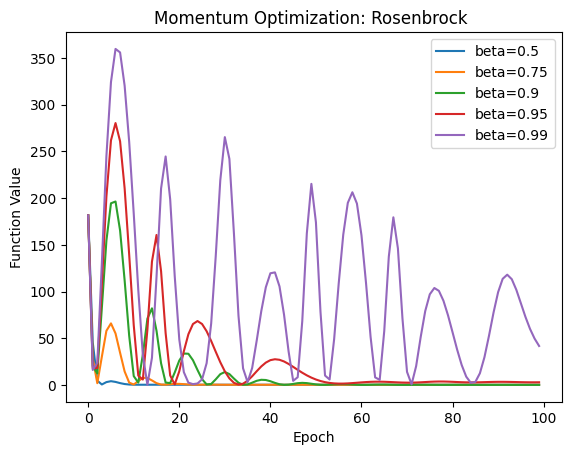

In [9]:
alpha = 1e-4
initial_solution = np.array([2.0, 2.0])
number_of_epochs = 100
beta_values = [0.5, 0.75, 0.9, 0.95, 0.99]


for beta in beta_values:
    pos, vals, v_norms = momentum(Rosenbrock(), initial_solution, alpha, beta, number_of_epochs)
    plt.plot(vals, label=f"beta={beta}")
plt.xlabel("Epoch")
plt.ylabel("Function Value")
plt.title("Momentum Optimization: Rosenbrock ")
plt.legend()
plt.show()



Increasing beta generally accelerates convergence, especially in areas of the error surface with low curvature, such as the long, flat valleys characteristic of the Rosenbrock function. When beta$is high (e.g., 0.9 to 0.99), the optimizer accumulates velocity in directions where the gradient is consistent.

While high momentum speeds up the journey, it significantly reduces stability. As beta approaches 1, the optimizer gains so much kinetic energy that it becomes difficult to brake when approaching a minimum. This leads to overshooting and high-frequency oscillations.

### 5. Adam
Implement the Adam optimizer:

```python
def adam(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta1: float,
    beta2: float,
    number_of_epochs: int,
    epsilon: float = 1e-8
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    ...
```

Where:
- beta1 is the exponential decay rate for first moment estimates (similar to momentum).
- beta2 is the exponential decay rate for second moment estimates (variance).

Returns a tuple of:
- positions: np.ndarray of shape (number_of_epochs, dim) — the optimization path.
- function_values: np.ndarray of shape (number_of_epochs,) — function value at each epoch.
- gradient_norms: np.ndarray of shape (number_of_epochs,) — gradient norm at each epoch.


In [26]:
def adam(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta1: float,
    beta2: float,
    number_of_epochs: int,
    epsilon: float = 1e-8
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    
    solution = initial_solution.copy()
    dim = solution.shape[0]
    m = np.zeros_like(solution)
    v = np.zeros_like(solution)

    positions = np.zeros((number_of_epochs, dim))
    function_values = np.zeros(number_of_epochs)
    gradient_norms = np.zeros(number_of_epochs)

    for epoch in range(number_of_epochs):
        grad = problem.grad(solution)

        positions[epoch] = solution.copy()
        function_values[epoch] = problem(solution)
        gradient_norms[epoch] = np.linalg.norm(grad)

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)

        m_hat = m / (1 - beta1 ** (epoch + 1))
        v_hat = v / (1 - beta2 ** (epoch + 1))

        solution = solution - alpha * m_hat / (np.sqrt(v_hat) + epsilon)

    return positions, function_values, gradient_norms

        




### 6. Comparing Adam with Momentum
Run both optimizers on Sphere, Rosenbrock and Rastrigin. Use: 
- `initial_solution = np.array([2.0, 2.0]), number_of_epochs = 100`.
- Momentum: `alpha = 0.01, beta = 0.9`.
- Adam: `alpha = 0.01, beta1 = 0.9, beta2 = 0.999, epsilon = 1e-8`.


Visualize optimization paths. Use `plot_contour_and_paths` to overlay paths from both methods.
Plot function value vs. epoch for both methods.

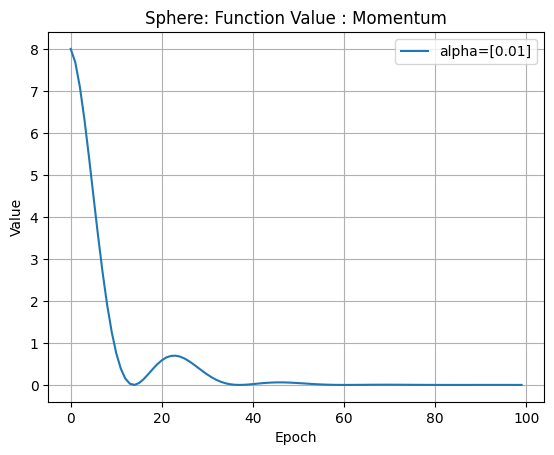

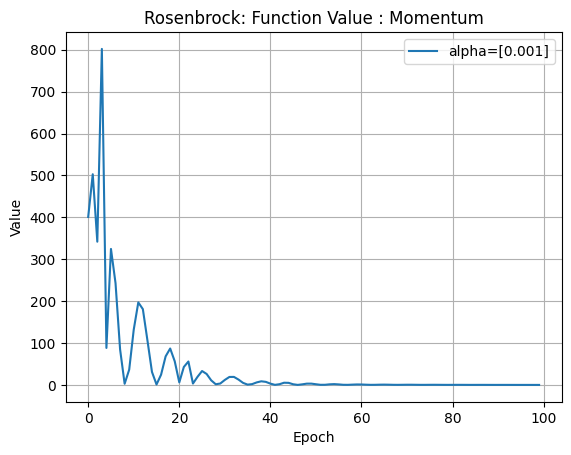

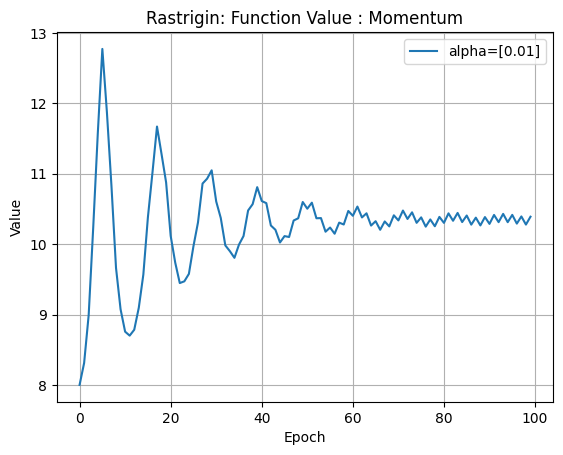

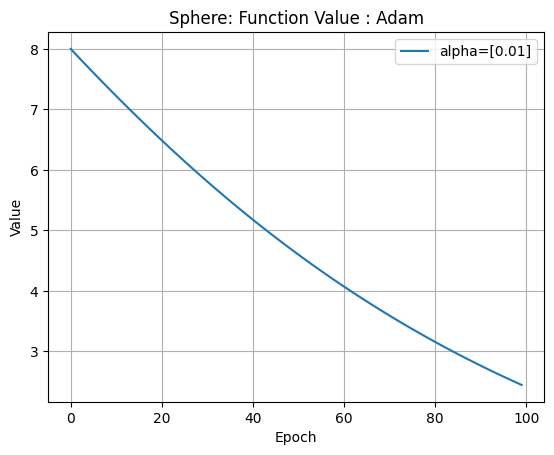

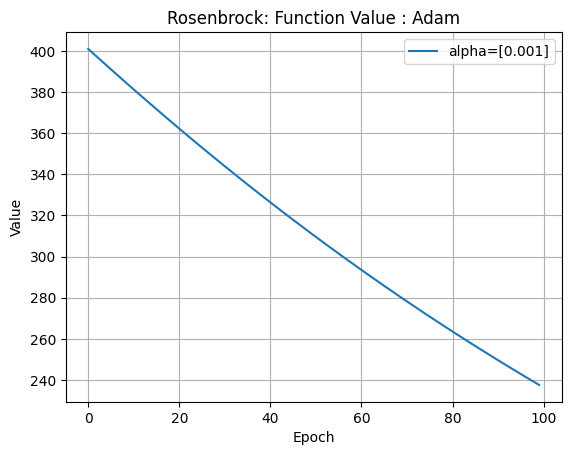

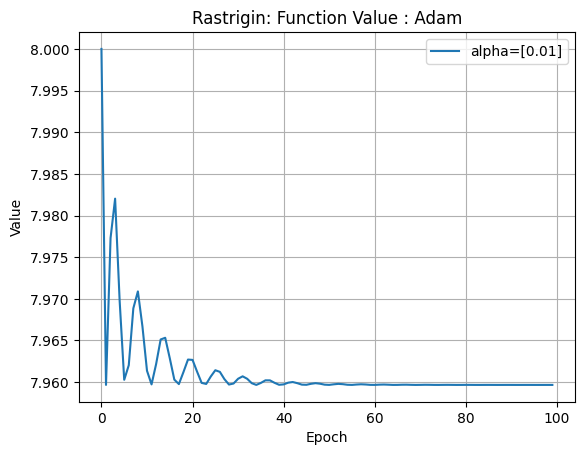

In [28]:
import numpy as np
import matplotlib.pyplot as plt

initial_solution = np.array([2.0, 2.0])
beta = 0.9
number_of_epochs = 100

problems = [("Sphere", Sphere(), [0.01]), 
            ("Rosenbrock", Rosenbrock(), [0.001]), 
            ("Rastrigin", Rastrigin(), [0.01])]

for i, (name, prob, alpha) in enumerate(problems):
    pos, vals, v_norms = momentum(prob, initial_solution, alpha, beta, number_of_epochs)
        
    plt.plot(vals, label=f"alpha={alpha}")
    plt.title(f"{name}: Function Value : Momentum")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()

    plot_contour_and_paths(
        problem=prob,
        paths=[pos],
        title=f"{name}: Optimization Path : Momentum"
    )
    plt.show()


alpha = 0.001
beta1 = 0.9
beta2 = 0.999 
epsilon = 1e-8


for i, (name, prob, alpha) in enumerate(problems):
    pos, vals, v_norms = adam(prob, initial_solution, alpha, beta1, beta2, number_of_epochs, epsilon)
        
    plt.plot(vals, label=f"alpha={alpha}")
    plt.title(f"{name}: Function Value : Adam")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()

    plot_contour_and_paths(
        problem=prob,
        paths=[pos],
        title=f"{name}: Optimization Path : Adam"
    )
    plt.show()

